

# Exploratory Data Analysis with Pandas Library


### Learning Objectives

- Define what Pandas is.
- Manipulate Pandas `DataFrames` and `Series`.
- Filter and sort data using Pandas.
- Manipulate `DataFrame` columns.
- Know how to handle null and missing values.

### Lesson Guide

- [What Is Pandas?](#pandas)
- [Reading Files, Selecting Columns, and Summarizing](#reading-files)
    - [Exercise 1](#exercise-one)
    
    
- [Filtering and Sorting](#filtering-and-sorting)
    - [Exercise 2](#exercise-two)
    
    
- [Renaming, Adding, and Removing Columns](#columns)
- [Handling Missing Values](#missing-values)
    - [Exercise 3](#exercise-three)
    
    
- [Split-Apply-Combine](#split-apply-combine)
    - [Exercise 4](#exercise-four)
    
    
- [Selecting Multiple Columns and Filtering Rows](#multiple-columns)
- [Joining (Merging) DataFrames](#joining-dataframes)
- [Apply / Map methods in Pandas](#other-features)
- [Other Less Used Features of Pandas](#uncommon-features)
- [Summary](#summary)

<a id="pandas"></a>

### What Is Pandas?

Pandas is a Python library for data manipulation and analysis. It offers data structures and operations for manipulating numerical tables and time series. The name is derived from the term "panel data", an econometrics term for data sets that include observations over multiple time periods for the same entities.Pandas is built on top of NumPy, and provides an efficient implementation of a DataFrame. DataFrames are essentially multidimensional arrays with attached row and column labels, and often with heterogeneous types and/or missing data.
NumPy's ndarray data structure provides essential features for the type of clean, well-organized data typically seen in numerical computing tasks. While it serves this purpose very well, its limitations become clear when we need more flexibility (e.g., attaching labels to data, working with missing data, etc.) and when attempting operations that do not map well to element-wise broadcasting (e.g., groupings, pivots, etc.), each of which is an important piece of analyzing the less structured data available in many forms in the world around us. Pandas, and in particular its Series and DataFrame objects, builds on the NumPy array structure and provides efficient access to these sorts of "data munging" tasks.

Pandas library adds two new datatypes to Python: `DataFrame` and `Series`.

- A `Series` is a sequence of items, where each item has a unique label (called an `index`).
- A `DataFrame` is a table of data. Each row has a unique label (the `row index`), and each column has a unique label (the `column index`).
- Note that each column in a `DataFrame` can be considered a `Series` (`Series` index).

> Behind the scenes, these datatypes use the NumPy ("Numerical Python") library. NumPy primarily adds the `ndarray` (n-dimensional array) datatype to Pandas. An `ndarray` is similar to a Python list — it stores ordered data. However, it differs in three respects:
> - Each element has the same datatype (typically fixed-size, e.g., a 32-bit integer).
> - Elements are stored contiguously (immediately after each other) in memory for fast retrieval.
> - The total size of an `ndarray` is fixed.

> Storing `Series` and `DataFrame` data in `ndarray`s makes Pandas faster and uses less memory than standard Python datatypes. Many libraries (such as scikit-learn) accept `ndarray`s as input rather than Pandas datatypes, so we will frequently convert between them.


### Using Pandas

Pandas is frequently used in data analytics because it offers a large set of commonly used functions, is relatively fast, and has a large community. Also, many data analytics libraries also use NumPy to manipulate data. Therefore, you can easily transfer data between libraries. Pandas is a large library that typically takes a lot of practice to learn.Pandas also highly favors certain patterns of use. For example, looping through a `DataFrame` row by row is highly discouraged. Instead, Pandas favors using **vectorized functions** that operate column by column. This is because each column is stored separately as an `ndarray`, and NumPy is optimized for operating on `ndarray`s. Please do not be discouraged if Pandas feels overwhelming for now. Gradually, as you use it, you will become familiar with which methods to use and the "Pandas way" of thinking about and manipulating data.

### Class Methods and Attributes

Pandas `DataFrame`s are Pandas class objects and therefore come with attributes and methods. To access these, follow the variable name with a dot. For example, given a `DataFrame` called `users`:

```
- users.index       # accesses the `index` attribute -- note there are no parentheses. attributes are not callable
- users.head()      # calls the `head` method (since there are open/closed parentheses)
- users.head(10)    # calls the `head` method with parameter `10`, indicating the first 10 rows. this is the same as:
- users.head(n=10)  # calls the `head` method, setting the named parameter `n` to have a value of `10`.
```

We know that the `head` method accepts one parameter with an optional name of `n` because it is in the documentation for that method. Let's see how to view the documentation next.

### Pandas

Just as we generally import NumPy under the alias ``np``, we will import Pandas under the alias ``pd``:

In [ ]:
!pip install pandas

In [ ]:
# Importing Pandas into Python
import pandas as pd

<a id="reading-files"></a>
### Reading Files, Selecting Columns, and Summarizing

In [ ]:
# Load in the data into a Pandas data frame with read_csv() method
url_link = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv'
titanic = pd.read_csv(url_link)

In [ ]:
type(titanic)

pandas.core.frame.DataFrame

**Examine the titanic data.**

In [ ]:
titanic = pd.read_csv('titanic.csv')

In [ ]:
# Print the first 5 and last 5 rows in the data
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# checking the data type of titanic object - DataFrame
type(titanic)

pandas.core.frame.DataFrame

In [ ]:
# print the first 5 rows
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# print the first 10 rows
titanic.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [ ]:
# print the last five rows
titanic.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
 # The row index ("the row labels" — in this case integers)
titanic.index

RangeIndex(start=0, stop=891, step=1)

In [ ]:
# Column names (which is "an index")
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
[titanic.columns]

[Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
        'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
       dtype='object')]

In [ ]:
list(titanic.columns)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
# creating a list of column names using list() function
list(titanic.columns)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
# Printing data types of each column using .dtypes attribute — each column is stored as an Numpy ndarray
titanic.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
# Checking the dimensions of the data using .shape attribute : number of rows and columns
titanic.shape

(891, 12)

In [ ]:
titanic.shape[0]

891

In [ ]:
num_of_rows = titanic.shape[0]
print(num_of_rows)

891


In [ ]:
# All values in the DataFrame as a NumPy array using .values attribute
titanic.values

array([[1, 0, 3, ..., 7.25, nan, 'S'],
       [2, 1, 1, ..., 71.2833, 'C85', 'C'],
       [3, 1, 3, ..., 7.925, nan, 'S'],
       ...,
       [889, 0, 3, ..., 23.45, nan, 'S'],
       [890, 1, 1, ..., 30.0, 'C148', 'C'],
       [891, 0, 3, ..., 7.75, nan, 'Q']], dtype=object)

In [ ]:
# .info() method provides a concise summary. It includes memory usage as well.
# It is useful to quickly see if nulls exist at any columns.
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


*** Select or index data.***<br>
A DataFrame acts in many ways like a two-dimensional or structured array, and in other ways like a dictionary of Series structures sharing the same index. These analogies can be helpful to keep in mind as we explore data selection within this structure. In the example below, we select a column of data using the name of the column in a similar manner to how we select a dictionary value with the dictionary key.

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
selected_columns = ["Name", "Age"]
titanic[selected_columns]

,Name,Age
0,"Braund, Mr. Owen Harris",22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0
4,"Allen, Mr. William Henry",35.0
...,...,...
886,"Montvila, Rev. Juozas",27.0
887,"Graham, Miss. Margaret Edith",19.0
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN
889,"Behr, Mr. Karl Howell",26.0


In [ ]:
# Selecting  a column: it returns a Pandas Series (it is essentially a Numpy ndarray with an index)
titanic[['Sex']]

,Sex
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


In [ ]:
titanic["Sex"]

,Sex
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


In [ ]:
# Checking the data type: DataFrame columns are Pandas Series.
type(titanic['Sex'])

pandas.core.series.Series

Alternatively, we can select one column using the DataFrame attribute. While using dot (.) operator is a useful shorthand, these attributes only exist if the column name has no punctuations or spaces.

In [ ]:
# Select one column using the DataFrame attribute.
titanic.Sex


,Sex
0,male
1,female
2,female
3,female
4,male
...,...
886,male
887,female
888,female
889,male


**Summarize (describe) the data.**<br>
Pandas has a bunch of built-in methods to quickly summarize your data and provide you with a quick general understanding. describe method provides descriptive statistics, excluding NaN values. For numeric data, the result’s index will include count, mean, std, min, max as well as lower, 50 and upper percentiles. By default the lower percentile is 25 and the upper percentile is 75. The 50 percentile is the same as the median.


In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Describe all object columns (can include multiple types).
# For object data (e.g. strings or timestamps),
# the result’s index will include count, unique, top, and freq, where
# the top is the most common value. The freq is the most common value’s frequency.
# Timestamps also include the first and last items.

titanic.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [ ]:
# We can exclude object columns from a DataFrame description with the help from numpy library.

import numpy as np
titanic.describe(exclude=[np.object])

<ipython-input-24-89e468ca30b2>:4: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  titanic.describe(exclude=[np.object])


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# We can exclude numeric columns from a DataFrame description as well.

import numpy as np
titanic.describe(exclude=[np.number])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [ ]:
# We can use .Series method to create a DataFrame
# We can include only categorical columns from a DataFrame description as follows:

s = pd.Series(['a', 'a', 'b', 'c'])
s.describe(include=['category'])

count     4
unique    3
top       a
freq      2
dtype: object

In [ ]:
# Describe all columns, including non-numeric.

# For mixed data types provided via a DataFrame, the default is to
# return only an analysis of numeric columns.
# If the dataframe consists only of object and categorical data without any numeric columns,
# the default is to return an analysis of both the object and categorical columns.
# If include='all' is provided as an option, the result will include a union of attributes of each type.

titanic.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [ ]:
# We can describe a single column — recall that "titanic.Sex" refers to a Pandas Series.
titanic.Sex.describe()

,Sex
count,891
unique,2
top,male
freq,577


In [ ]:
# We can use .mean() method to calculate the average of the Age column.
titanic.Age.mean()

29.69911764705882

In [ ]:
# We can use .std() method to calculate the standard deviation of the Age column.
titanic.Age.std()

14.526497332334044

In [ ]:
# We can use .count() method to count the number of non-NA/null observations in Age column.
titanic.Age.count()

714

In [ ]:
# Maximum and Minimum of the values in the object.
print("maximum age in Titanic is", titanic.Age.max())
print("minimum age in Titanic is ", titanic.Age.min())

maximum age in Titanic is 80.0
minimum age in Titanic is  0.42


<Axes: >

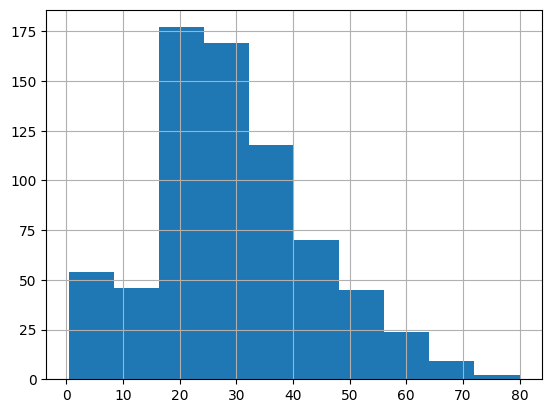

In [ ]:
# We can plot a histogram of a column (the distribution of values in Age column).

titanic.Age.hist()

**Count the number of occurrences of each value.**

In [ ]:
# .value_counts() method is very useful for categorial variables.
# It provides us the unique counts of categorical variables.
titanic.Sex.value_counts()

,count
Sex,
male,577
female,314


In [ ]:
titanic.Pclass.value_counts()

,count
Pclass,
3,491
1,216
2,184


<Axes: xlabel='Sex'>

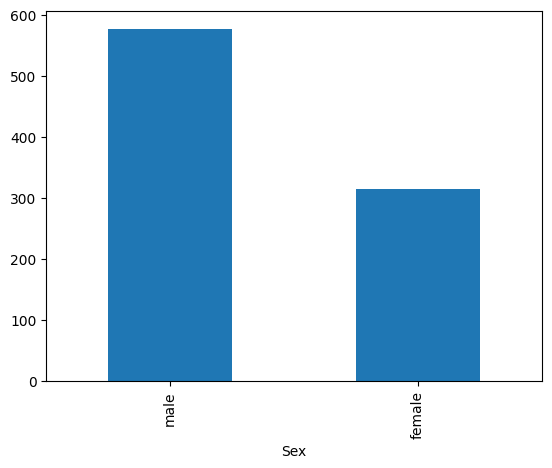

In [ ]:
# We can create a quick plot by category
titanic.Sex.value_counts().plot(kind='bar')

<Axes: >

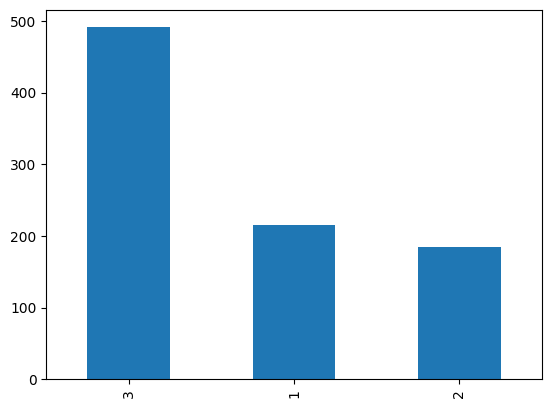

In [ ]:

titanic.Pclass.value_counts().plot(kind='bar')

In [ ]:
# .value_counts() can also be used with numeric variables. It also goes well together with .sort_index() / .sort_values()
# .sort_index() sorts by indices.
# .sort_values() sorts by counts.

titanic.Age.value_counts()

24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: Age, Length: 88, dtype: int64

It shows us that there are 30 passengers who are 24 years old; there are 25 passengers who are 30 years old.

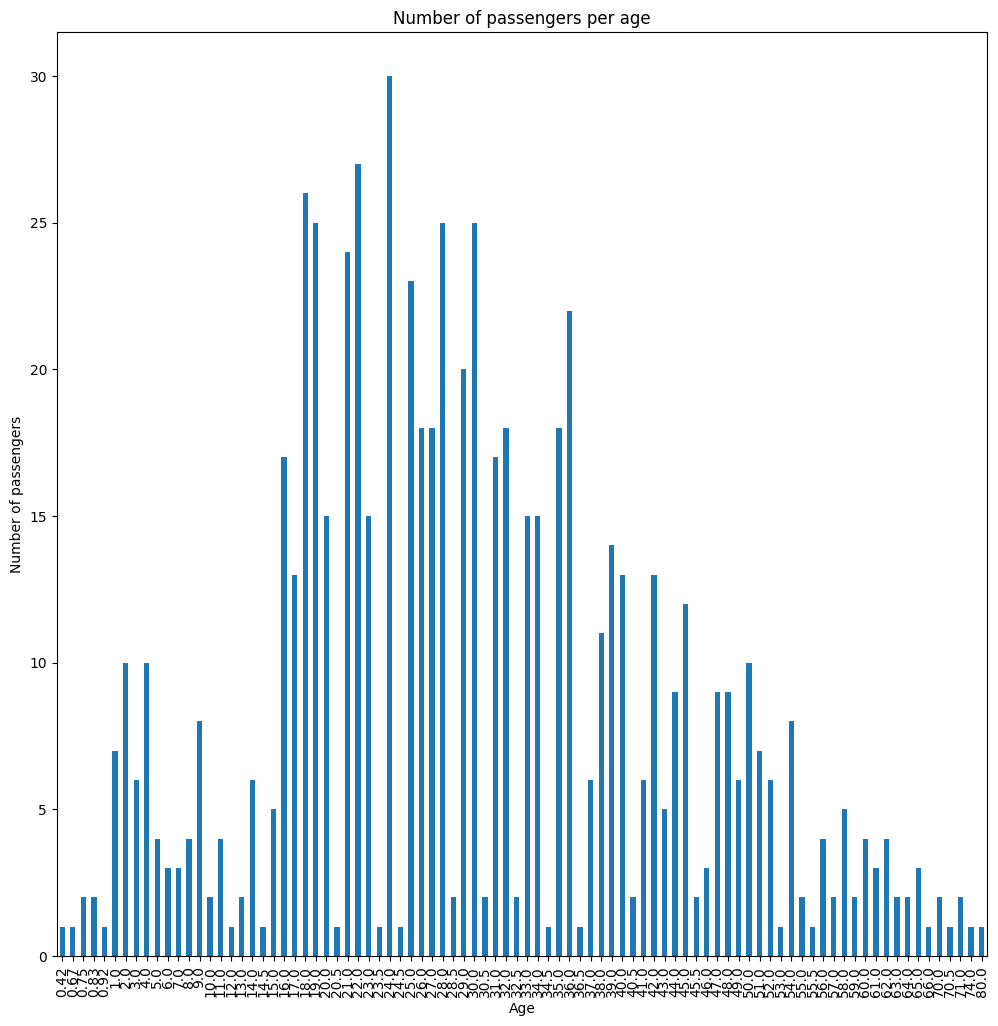

In [ ]:
# We can import matplotlib to add axes labels and plot title
import matplotlib.pyplot as plt
%matplotlib inline


titanic.Age.value_counts().sort_index().plot(kind='bar', figsize=(12,12));
plt.xlabel('Age');
plt.ylabel('Number of passengers');
plt.title('Number of passengers per age');

<Axes: >

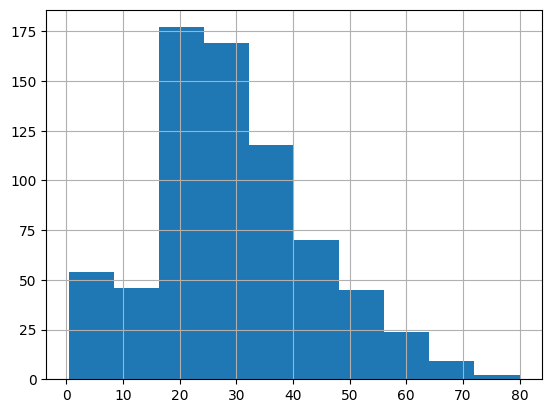

In [ ]:
titanic.Age.hist()

<a id="exercise-one"></a>
### Exercise 1

In [2]:
# Read tips.csv into a DataFrame called "tips".
import pandas as pd

url_link = 'tips.csv'
tips = pd.read_csv(url_link)

In [3]:
# Print the head and the tail of the DataFrame
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
url_link_alternative = 'https://gist.githubusercontent.com/ryanorsinger/0c702f67dfe59346cd4677cd24f7aec7/raw/429f0d47856670e57b31d1f78a1abc54c889c7ca/tips.csv'

In [5]:
my_data = pd.read_csv(url_link_alternative)

In [6]:
my_data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [7]:
# Examine the default index, datatypes, and shape.

tips.index

RangeIndex(start=0, stop=244, step=1)

In [9]:
tips.dtypes

,0
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


In [8]:
tips.shape

(244, 7)

In [ ]:
# Print the total_bill Series.

tips.total_bill

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

In [ ]:
tips['total_bill']

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

In [ ]:
# Calculate the average total_bill for the entire data set.
tips.total_bill.mean()

19.78594262295082

In [10]:
tips[["total_bill",'size']]

,total_bill,size
0,16.99,2
1,10.34,3
2,21.01,3
3,23.68,2
4,24.59,4
...,...,...
239,29.03,3
240,27.18,2
241,22.67,2
242,17.82,2


In [11]:
tips[["total_bill",'size']].mean()

,0
total_bill,19.785943
size,2.569672


In [12]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Count the number of unique occurrences of categorical variables in the data set
tips.value_counts()


total_bill  tip    sex     smoker  day   time    size
13.00       2.00   Female  Yes     Thur  Lunch   2       2
3.07        1.00   Female  Yes     Sat   Dinner  1       1
22.23       5.00   Male    No      Sun   Dinner  2       1
20.69       2.45   Female  No      Sat   Dinner  4       1
            5.00   Male    No      Sun   Dinner  5       1
                                                        ..
15.53       3.00   Male    Yes     Sat   Dinner  2       1
15.69       1.50   Male    Yes     Sun   Dinner  2       1
            3.00   Male    Yes     Sat   Dinner  3       1
15.77       2.23   Female  No      Sat   Dinner  2       1
50.81       10.00  Male    Yes     Sat   Dinner  3       1
Length: 243, dtype: int64

In [13]:
tips.sex.value_counts()

,count
sex,
Male,157
Female,87


In [14]:
tips.smoker.value_counts()

,count
smoker,
No,151
Yes,93


In [15]:
tips.day.value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [16]:
tips.time.value_counts()

,count
time,
Dinner,176
Lunch,68


<a id="filtering-and-sorting"></a>
### Filtering and Sorting Data using Pandas

We can use simple operator comparisons on columns to extract relevant or drop irrelevant information.

In [17]:
import pandas as pd

url_link = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv'
titanic = pd.read_csv(url_link)

In [ ]:
18 < 20

True

In [ ]:
4 == 5

False

In [18]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic.Age < 20

,Age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,True
888,False
889,False


**Logical filtering: Only show users with age < 20.**

In [19]:
# Let us create a Pandas Series of Booleans...
# In Pandas, this comparison is performed element-wise on each row of data.

young_bool = titanic.Age < 20
young_bool

,Age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,True
888,False
889,False


In [20]:
# We can use that Series to filter rows.
# In Pandas, indexing a DataFrame by a Series of Booleans only selects rows that are True in the Boolean.
titanic[young_bool]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
869,870,1,3,"Johnson, Master Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


In [21]:
# Alternatively, we can combine the above two steps into a single one as follows:
titanic[titanic.Age < 20]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
869,870,1,3,"Johnson, Master Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


In [23]:
titanic[titanic.Sex == 'female']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
882,883,0,3,"Dahlberg, Miss Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [24]:
titanic.loc[titanic.Age<20]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
869,870,1,3,"Johnson, Master Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


It is important to note that the above filtering creates a view of the original DataFrame, not a new DataFrame. If you alter this view (e.g., by storing it in a variable and altering that) You will change only the slice of the DataFrame and not the actual DataFrame itself. Here, notice that Pandas gives you a SettingWithCopyWarning to alert you of this.

In [25]:
titanic_under20 = titanic[titanic.Age < 20].copy()
titanic_under20

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
869,870,1,3,"Johnson, Master Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


In [26]:
titanic_under20["my new column"] = "HAPPY"
titanic_under20

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,my new column
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,HAPPY
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,HAPPY
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,HAPPY
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S,HAPPY
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q,HAPPY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,HAPPY
869,870,1,3,"Johnson, Master Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S,HAPPY
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,HAPPY
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S,HAPPY


In [ ]:
# It is best practice to use .loc and .iloc instead of the syntax below
titanic_under20 = titanic[titanic.Age < 20].copy()   # We copy the `DataFrame` using `.copy()` method here.
titanic_under20['newColumn'] = 0
titanic_under20

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,newColumn
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,0
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,0
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S,0
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,0
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S,0
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,0
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S,0


In [27]:
# We can select a single column from the filtered results as follows:
titanic[titanic.Age < 20].Pclass

,Pclass
7,3
9,2
10,3
14,3
16,3
...,...
855,3
869,3
875,3
877,3


In [28]:
# We can count unique values of resulting Series using value_counts as follows:
titanic[titanic.Age < 20].Pclass.value_counts()

,count
Pclass,
3,108
2,35
1,21


**Logical filtering with multiple conditions**

In [29]:
4 < 5 and 3 < 8

True

In [30]:
4 < 5 and 3 > 9

False

In [31]:
4 < 5 or 3 > 9

True

In [32]:
# Ampersand (&) for `AND` condition. (This is a "bitwise" `AND`.)
# Important: You MUST put parentheses around each expression because `&` has a higher precedence than `<`.

titanic[(titanic.Age < 20) & (titanic.Sex=='female')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
22,23,1,3,"McGowan, Miss Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
24,25,0,3,"Palsson, Miss Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
852,853,0,3,"Boulos, Miss Nourelain",female,9.0,1,1,2678,15.2458,NaN,C
853,854,1,1,"Lines, Miss Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C


In [35]:
titanic[(titanic.Age < 20) & (titanic.Sex=='female') & (titanic.Fare >= 25)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
43,44,1,2,"Laroche, Miss Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C
58,59,1,2,"West, Miss Constance Mirium",female,5.0,1,2,C.A. 34651,27.7500,NaN,S
71,72,0,3,"Goodwin, Miss Lillian Amy",female,16.0,5,2,CA 2144,46.9000,NaN,S
119,120,0,3,"Andersson, Miss Ellis Anna Maria",female,2.0,4,2,347082,31.2750,NaN,S
136,137,1,1,"Newsom, Miss Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S
147,148,0,3,"Ford, Miss Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,NaN,S
233,234,1,3,"Asplund, Miss Lillian Gertrud",female,5.0,4,2,347077,31.3875,NaN,S
237,238,1,2,"Collyer, Miss Marjorie ""Lottie""",female,8.0,0,2,C.A. 31921,26.2500,NaN,S
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,B49,C


In [36]:
# Pipe for `OR` condition. (This is a "bitwise" `OR`.)
# Important: You MUST put parentheses around each expression because `|` has a higher precedence than `<`.
titanic[(titanic.Age < 20) | (titanic.Age > 60)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
869,870,1,3,"Johnson, Master Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S


In [ ]:
"cat" in ["cat", "dog"]

True

In [37]:
titanic.Embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [38]:
titanic.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [39]:
# We note that the following is a preferred alternative to multiple `OR` conditions using .isin() method:

titanic[titanic.Embarked.isin(['C', 'Q'])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [40]:
titanic[(titanic.Embarked == 'C') | (titanic.Embarked == "Q") ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
16,17,0,3,"Rice, Master Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
titanic.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [ ]:
titanic.loc[(titanic.Embarked == "S") | (titanic.Embarked == "Q")]
titanic.loc[titanic.Embarked.isin(["S", "Q"])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


**Sorting**

In [41]:
# We can sort a Series in a DataFrame using .sort_values() method.
titanic.Fare.sort_values()

,Fare
271,0.0000
597,0.0000
302,0.0000
633,0.0000
277,0.0000
...,...
438,263.0000
341,263.0000
737,512.3292
258,512.3292


In [ ]:
# We can also calll sort_values on the DataFrame itself with a choice of column
# Sort a DataFrame by a single column.

titanic.sort_values('Fare')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0000,NaN,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0000,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0000,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C


In [42]:
# Default sorting mechanism for sort_values is increasing (asceding).
# We can set the defailt value ascending parameter to False and use descending order instead.

titanic.sort_values('Fare', ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
88,89,1,1,"Fortune, Miss Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...,...
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0000,NaN,S
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S
732,733,0,2,"Knight, Mr. Robert J",male,NaN,0,0,239855,0.0000,NaN,S


In [ ]:
# We can also sort the DataFrame by multiple columns.
titanic.sort_values(['Fare', 'Age'], ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...,...
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S
674,675,0,2,"Watson, Mr. Ennis Hastings",male,NaN,0,0,239856,0.0000,NaN,S
732,733,0,2,"Knight, Mr. Robert J",male,NaN,0,0,239855,0.0000,NaN,S


<a id="exercise-two"></a>
### Exercise 2
Use the `tips.csv` or `tips` `DataFrame` from earlier to complete the following.

In [45]:
import pandas as pd

url_link = 'https://gist.githubusercontent.com/ryanorsinger/0c702f67dfe59346cd4677cd24f7aec7/raw/429f0d47856670e57b31d1f78a1abc54c889c7ca/tips.csv'
tips = pd.read_csv(url_link)

In [ ]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [46]:
tips.time.value_counts()

,count
time,
Dinner,176
Lunch,68


In [ ]:
# Filter DataFrame to only include Dinner rows.

tips[tips.time == 'Dinner']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# Filter DataFrame to only include Dinner rows with tip > 3.

tips[(tips.time == 'Dinner') & (tips.tip > 3)]


,total_bill,tip,sex,smoker,day,time,size
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
7,26.88,3.12,Male,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
214,28.17,6.50,Female,Yes,Sat,Dinner,3
219,30.14,3.09,Female,Yes,Sat,Dinner,4
232,11.61,3.39,Male,No,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3


In [47]:
# Calculate the average tip for all Dinner rows.

tips[ tips.time == 'Dinner'].tip.mean()


3.102670454545454

In [48]:
tips[ tips.time == 'Dinner'].tip.max()

10.0

In [49]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [52]:
# Determine which 2 days have the highest tip.

tips.sort_values('tip', ascending=False).head(2)


,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.0,Male,Yes,Sat,Dinner,3
212,48.33,9.0,Male,No,Sat,Dinner,4


<a id="columns"></a>
### Renaming, Adding, and Removing Columns:  Manipulating `DataFrame` columns.

In [53]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [57]:
tips[["total_bill",'size','tip']].corr()

,total_bill,size,tip
total_bill,1.000000,0.598315,0.675734
size,0.598315,1.000000,0.489299
tip,0.675734,0.489299,1.000000


<Axes: xlabel='tip', ylabel='total_bill'>

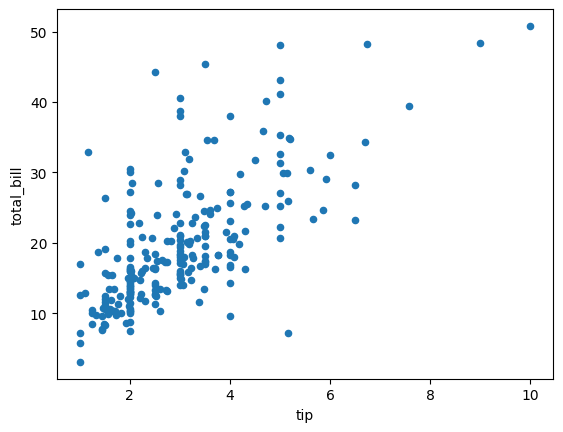

In [58]:
# Are tip amount and total bill correlated?
tips.plot(kind='scatter', x='tip', y='total_bill')

In [59]:
# We can rename one or more columns in a single output using value mapping.
# Columns --> dictionary key: value

tips.rename(columns={'total_bill':'total'})

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [60]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [61]:
# Rename one or more columns in the original DataFrame.
# importance of inplace = True parameter

tips.rename(columns={'total_bill':'total'}, inplace=True)
tips.head()

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [62]:
tips

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# We can also use names parameter in read_csv method while we are uploading the data

# Replace all column names using a list of matching length.
tips_cols = ['total', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

# Replace during file reading (disables the header from the file).
tips = pd.read_csv(url_link, header=0, names=tips_cols)
tips.head()

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# We can also replace column names after file has already been read into Python.
tips.columns = tips_cols
tips.head()

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Easy Column Operations**<br>
Rather than having to reference indexes and create for loops to do column-wise operations, Pandas is smart and knows that when we add columns together we want to add the values in each row together.

In [63]:
tips

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [64]:
# Add a new column as a function of existing columns.
tips['tipPercent'] = tips.tip / tips.total * 100

tips.head()

,total,tip,sex,smoker,day,time,size,tipPercent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


**Removing Columns**

In [65]:
# In Pandas, axis parameter takes two values:
# axis=0 for rows, axis = 1 for columns
tips.drop('tipPercent', axis=1)

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# We can also drop multiple columns using .drop method, which takes a list of column names to drop from the DataFrame
tips.drop(['tipPercent'], axis=1)

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [66]:
tips

,total,tip,sex,smoker,day,time,size,tipPercent
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [67]:
# Drop on the original DataFrame rather than returning a new one.
# Importance of inplace = True parameter

tips.drop(['tipPercent'], axis=1, inplace=True)


In [68]:
tips

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<a id="missing-values"></a>
### Handling Missing Values

When we are conducting exploratory data analysis, it is important to know how to handle null and missing values. Sometimes, values will be missing from the source data or as a byproduct of manipulations. It is very important to detect missing data. Missing data can:

- Make the entire row ineligible to be training data for a model.
- Hint at data-collection errors.
- Indicate improper conversion or manipulation.
- Actually not be missing — it sometimes means "zero," "false," "not applicable," or "entered an empty string."

For example, a `.csv` file might have a missing value in some data fields:

```
tool_name,material,cost
hammer,wood,8
chainsaw,,
wrench,metal,5
```

When this data is imported, "null" values will be stored in the second row (in the "material" and "cost" columns).

> In Pandas, a "null" value is either `None` or `np.NaN` (Not a Number). Many fixed-size numeric datatypes (such as integers) do not have a way of representing `np.NaN`. So, numeric columns will be promoted to floating-point datatypes that do support it. For example, when importing the `.csv` file above:

> - **For the second row:** `None` will be stored in the "material" column and `np.NaN` will be stored in the "cost" column. The entire "cost" column (stored as a single `ndarray`) must be stored as floating-point values to accommodate the `np.NaN`, even though an integer `8` is in the first row.

In [69]:

# When we use .value_counts() method, missing values are excluded in calculations by default.
titanic.Age.value_counts()              # Excludes missing values in the calculation


,count
Age,
24.00,30
22.00,27
18.00,26
19.00,25
28.00,25
...,...
36.50,1
55.50,1
0.92,1


In [76]:
# We can explicitly include missing values by setting the parameter dropna to False as follows:
titanic.Age.value_counts(dropna=False)


,count
Age,
NaN,177
24.00,30
22.00,27
18.00,26
28.00,25
...,...
36.50,1
55.50,1
0.92,1


In [77]:
# Find missing values in a Series uding .isnull(); it returns a Boolean result
# True if missing, False if not missing
titanic.Age.isnull()



,Age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,True
889,False


In [78]:
# We can use .sum() method along with .isnull() to count the number of missing values
# Count the missing values — sum() works because True is 1 and False is 0.
titanic.Age.isnull().sum()


177

In [79]:
# Alternative to .isnull(), it is .notnull() method; it returns a Boolean result as well.
# True if not missing, False if missing
titanic.Age.notnull()


,Age
0,True
1,True
2,True
3,True
4,True
...,...
886,True
887,True
888,False
889,True


In [80]:
# We can also filter the DataFrame using the results of .isnull() and .notnull() methods
# Only show rows where Age is not missing.
titanic[titanic.Age.notnull()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


***Understanding Pandas Axis***

In [83]:
# axis=0 is the default. Summing over the rows in a column is the default action
titanic['Age'].sum()


21205.17

In [86]:
# Sums "across" the 1 axis (columns) — so, we get the sums of numeric values in the row
titanic['Age'].sum(axis=0)


21205.17

In [87]:
titanic['Age'].sum(axis=1)

ValueError: No axis named 1 for object type Series

**Find missing values in a `DataFrame`.**

In [88]:
# We can call .isnull() method on the entire DataFrame to get a DataFrame of Booleans to identify missing values
titanic.isnull()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [89]:
# We can call .isnull() method on the entire DataFrame to get a DataFrame of Booleans to identify missing values
titanic.isnull().any()


,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


In [ ]:
# Count the missing values in each column — remember by default, axis=0.
print((titanic.isnull().sum()))

titanic.isnull().sum().plot(kind='bar');         # visually show the count of missing values in the DataFrame
plt.title('Number of null values per column');

**Dropping Missing Values**

In [90]:
# We can drop a row if ANY values are missing from any column — however, it can be dangerous!
titanic.dropna()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [91]:
# Alternatively, we can drop a row only if ALL values are missing.
titanic.dropna(how='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**Filling Missing Values**<br>

One way of imputing numerical features is to replace missing values with the average values. Similarly, one approach to imputing categorical features is to replace missing values with the most common class. You can do with by taking the index of the most common feature given in Pandas' value_counts function.


In [92]:
titanic.Age.fillna(value = titanic.Age.mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [94]:
titanic.Cabin.value_counts(dropna=False)

,count
Cabin,
NaN,687
C23 C25 C27,4
G6,4
B96 B98,4
C22 C26,3
...,...
E34,1
C7,1
C54,1


In [95]:
titanic.Cabin.fillna(value = titanic.Cabin.value_counts()[0])

<ipython-input-95-818ac530b150>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  titanic.Cabin.fillna(value = titanic.Cabin.value_counts()[0])


,Cabin
0,4
1,C85
2,4
3,C123
4,4
...,...
886,4
887,B42
888,4
889,C148


In [98]:
# If we would like to make this imputation permanent, we can set inplace parameter to True

titanic.Cabin.fillna(value = titanic.Cabin.value_counts()[0], inplace = True)

KeyError: 0

In [99]:
titanic.Age.fillna(value = titanic.Age.mean(), inplace=True)

<ipython-input-99-79a4546fc1b4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.Age.fillna(value = titanic.Age.mean(), inplace=True)


In [101]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<a id="exercise-three"></a>
### Exercise 3

In [ ]:
# Read ufo.csv into a DataFrame called "ufo".
ufo_data_link = 'https://raw.githubusercontent.com/planetsig/ufo-reports/master/csv-data/ufo-scrubbed-geocoded-time-standardized.csv'

column_names = ['datetime', 'city', 'state', 'country', 'shapeSeen', 'duration(seconds)', 'duration(hours/min)', 'comments', 'date posted', 'lon', 'lat']
ufo = pd.read_csv(ufo_data_link, header=0, names=column_names, low_memory=False)

In [ ]:
ufo.head()

,datetime,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments,date posted,lon,lat
0,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
1,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
2,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
3,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
4,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889


In [ ]:
# Check the shape of the DataFrame.
ufo.shape


(80331, 11)

In [ ]:
# What are the three most common shapes (shapeSeen) reported?
ufo.shapeSeen.value_counts()


light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
cigar         2057
changing      1962
flash         1328
rectangle     1297
cylinder      1282
diamond       1178
chevron        952
egg            759
teardrop       750
cone           316
cross          233
delta            7
round            2
crescent         2
changed          1
dome             1
flare            1
hexagon          1
pyramid          1
Name: shapeSeen, dtype: int64

In [ ]:
# Rename any columns with spaces so that they don't contain spaces.




In [ ]:
# Print a DataFrame containing only reports from Arlington, VA.




In [ ]:
# Count the number of missing values in each column.

ufo.isnull().sum()


datetime                  0
city                      0
state                  5797
country                9670
shapeSeen              1932
duration(seconds)         0
duration(hours/min)       0
comments                 15
date posted               0
lon                       0
lat                       0
dtype: int64

In [ ]:
# How many rows remain if you drop all rows with any missing values?

ufo.dropna()


,datetime,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments,date posted,lon,lat
2,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
3,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
4,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889
6,10/10/1965 23:45,norwalk,ct,us,disk,1200,20 minutes,A bright orange color changing to reddish colo...,10/2/1999,41.1175000,-73.408333
7,10/10/1966 20:00,pell city,al,us,disk,180,3 minutes,Strobe Lighted disk shape object observed clos...,3/19/2009,33.5861111,-86.286111
...,...,...,...,...,...,...,...,...,...,...,...
80326,9/9/2013 21:15,nashville,tn,us,light,600,10 minutes,Round from the distance/slowly changing colors...,9/30/2013,36.1658333,-86.784444
80327,9/9/2013 22:00,boise,id,us,circle,1200,20 minutes,Boise&#44 ID&#44 spherical&#44 20 min&#44 10 r...,9/30/2013,43.6136111,-116.202500
80328,9/9/2013 22:00,napa,ca,us,other,1200,hour,Napa UFO&#44,9/30/2013,38.2972222,-122.284444
80329,9/9/2013 22:20,vienna,va,us,circle,5,5 seconds,Saw a five gold lit cicular craft moving fastl...,9/30/2013,38.9011111,-77.265556


<a id="split-apply-combine"></a>
### Split-Apply-Combine

Split-apply-combine is a pattern for analyzing data. Suppose we want to find mean beer consumption per continent. Then:

- **Split:** We group data by continent.
- **Apply:** For each group, we apply the `mean()` function to find the average beer consumption.
- **Combine:** We now combine the continent names with the `mean()`s to produce a summary of our findings.

In [102]:
tips

,total,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [103]:
tips.groupby("sex").tip.mean()

,tip
sex,
Female,2.833448
Male,3.089618


In [104]:
# Using tips DataFrame earlier (tips.csv). For each meal time, calculate the mean tip.
tips.groupby('time').tip.mean()

,tip
time,
Dinner,3.102670
Lunch,2.728088


In [107]:
# For each meal time, calculate the mean of all numeric columns.
tips.groupby('time')[['size','tip']].mean()

,size,tip
time,,
Dinner,2.630682,3.102670
Lunch,2.411765,2.728088


In [ ]:
# For each meal time, describe tip.
tips.groupby('time').tip.describe()


,count,mean,std,min,25%,50%,75%,max
time,,,,,,,,
Dinner,176.0,3.102670,1.436243,1.00,2.0,3.00,3.6875,10.0
Lunch,68.0,2.728088,1.205345,1.25,2.0,2.25,3.2875,6.7


In [ ]:
# Similar, but outputs a DataFrame and can be customized — "agg" allows you to aggregate results of Series functions
tips.groupby('time').tip.agg(['count', 'mean', 'min', 'max'])
tips.groupby('time').tip.agg(['count', 'mean', 'min', 'max']).sort_values('mean')



,count,mean,min,max
time,,,,
Lunch,68,2.728088,1.25,6.7
Dinner,176,3.102670,1.00,10.0


In [ ]:
# For each meal time, describe all numeric columns.
tips.groupby('time').describe()

total                                      ... size                    
        count       mean       std   min      25%  ...  min  25%  50%  75%  max
time                                               ...                         
Dinner  176.0  20.797159  9.142029  3.07  14.4375  ...  1.0  2.0  2.0  3.0  6.0
Lunch    68.0  17.168676  7.713882  7.51  12.2350  ...  1.0  2.0  2.0  2.0  6.0

[2 rows x 24 columns]

In [ ]:
# For each meal time, count the number of rows.
print((tips.groupby('time').time.count()))
print((tips.time.value_counts()))   # it should yield the same output.

time
Dinner    176
Lunch      68
Name: time, dtype: int64
Dinner    176
Lunch      68
Name: time, dtype: int64


<a id="exercise-four"></a>
### Exercise 4

Use the "titanic" `DataFrame` that we have loaded earlier to complete the following.

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# For each passenger class (Pclass) in "titanic", count the number of occurrences.
titanic.Pclass.value_counts()


3    491
1    216
2    184
Name: Pclass, dtype: int64

In [ ]:
titanic.groupby('Pclass').Pclass.count()

Pclass
1    216
2    184
3    491
Name: Pclass, dtype: int64

In [ ]:
# For each passenger class (Pclass), calculate the mean age.

titanic.groupby('Pclass').Age.mean()


Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [ ]:
# For each passenger class (Pclass), calculate the minimum and maximum ages.

print(titanic.groupby('Pclass').Age.min())
print(titanic.groupby('Pclass').Age.max())


Pclass
1    0.92
2    0.67
3    0.42
Name: Age, dtype: float64
Pclass
1    80.0
2    70.0
3    74.0
Name: Age, dtype: float64


In [ ]:
# For each combination of passenger class (Pclass) and gender (Sex), calculate the mean age.

titanic.groupby(['Pclass', 'Sex']).Age.mean()

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64

----

<a id="multiple-columns"></a>
### Selecting Multiple Columns and Filtering Rows

Let us use the ufo DataFrame that we have loaded earlier in the following:

In [ ]:
# loading again (in case you need to)
# Read ufo.csv into a DataFrame called "ufo".
ufo_data_link = 'https://raw.githubusercontent.com/planetsig/ufo-reports/master/csv-data/ufo-scrubbed-geocoded-time-standardized.csv'

column_names = ['datetime', 'city', 'state', 'country', 'shapeSeen', 'duration(seconds)', 'duration(hours/min)', 'comments', 'date posted', 'lon', 'lat']
ufo = pd.read_csv(ufo_data_link, header=0, names=column_names, low_memory=False)

In [ ]:
ufo.head()

,datetime,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments,date posted,lon,lat
0,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
1,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
2,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
3,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
4,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889


In [ ]:
# Select multiple columns — yet another overload of the DataFrame indexing operator!
my_cols = ['city', 'state']     # Create a list of column names...
ufo[my_cols]                    # ...and use that list to select columns.

,city,state
0,lackland afb,tx
1,chester (uk/england),NaN
2,edna,tx
3,kaneohe,hi
4,bristol,tn
...,...,...
80326,nashville,tn
80327,boise,id
80328,napa,ca
80329,vienna,va


In [ ]:
# Or, combine into a single step (this is a Python list inside of the Python index operator!).
ufo[['city', 'state']]

,city,state
0,lackland afb,tx
1,chester (uk/england),NaN
2,edna,tx
3,kaneohe,hi
4,bristol,tn
...,...,...
80326,nashville,tn
80327,boise,id
80328,napa,ca
80329,vienna,va


**Use `loc` to select columns by name.**

In [ ]:
# "loc" locates the values from the first parameter (colon means "all rows"), and the column "city".
ufo.loc[:, 'city']



0                lackland afb
1        chester (uk/england)
2                        edna
3                     kaneohe
4                     bristol
                 ...         
80326               nashville
80327                   boise
80328                    napa
80329                  vienna
80330                  edmond
Name: city, Length: 80331, dtype: object

In [ ]:
# Select two columns.
ufo.loc[:, ['city', 'state']]

,city,state
0,lackland afb,tx
1,chester (uk/england),NaN
2,edna,tx
3,kaneohe,hi
4,bristol,tn
...,...,...
80326,nashville,tn
80327,boise,id
80328,napa,ca
80329,vienna,va


In [ ]:
# Select a range of columns — unlike Python ranges, Pandas index ranges INCLUDE the final column in the range.
ufo.loc[:, 'city':'comments']

,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments
0,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...
1,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...
2,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...
3,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...
4,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...
...,...,...,...,...,...,...,...
80326,nashville,tn,us,light,600,10 minutes,Round from the distance/slowly changing colors...
80327,boise,id,us,circle,1200,20 minutes,Boise&#44 ID&#44 spherical&#44 20 min&#44 10 r...
80328,napa,ca,us,other,1200,hour,Napa UFO&#44
80329,vienna,va,us,circle,5,5 seconds,Saw a five gold lit cicular craft moving fastl...


In [ ]:
# "loc" can also filter rows by "name" (the index).
# Row 0, all columns
ufo.loc[0, :]

datetime                                                10/10/1949 21:00
city                                                        lackland afb
state                                                                 tx
country                                                              NaN
shapeSeen                                                          light
duration(seconds)                                                   7200
duration(hours/min)                                              1-2 hrs
comments               1949 Lackland AFB&#44 TX.  Lights racing acros...
date posted                                                   12/16/2005
lon                                                             29.38421
lat                                                             -98.5811
Name: 0, dtype: object

In [ ]:
# Rows 0/1/2, all columns
ufo.loc[0:2, :]

,datetime,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments,date posted,lon,lat
0,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
1,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
2,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833


In [ ]:
# Rows 0/1/2, range of columns
ufo.loc[0:2, 'city':'comments']

,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments
0,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...
1,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...
2,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...


In [ ]:
# Use "iloc" to filter rows and select columns by integer position.
# (Remember that rows/columns use indices, so "iloc" lets you refer to indices via their index rather than value!)
# All rows, columns in position 0/3 (City/State)
ufo.iloc[:, [0, 3]]

,datetime,country
0,10/10/1949 21:00,NaN
1,10/10/1955 17:00,gb
2,10/10/1956 21:00,us
3,10/10/1960 20:00,us
4,10/10/1961 19:00,us
...,...,...
80326,9/9/2013 21:15,us
80327,9/9/2013 22:00,us
80328,9/9/2013 22:00,us
80329,9/9/2013 22:20,us


In [ ]:
# All rows, columns in position 0/1/2/3
# Note here it is NOT INCLUDING 4 because this is an integer range, not a Pandas index range!
ufo.iloc[:, 0:4]

,datetime,city,state,country
0,10/10/1949 21:00,lackland afb,tx,NaN
1,10/10/1955 17:00,chester (uk/england),NaN,gb
2,10/10/1956 21:00,edna,tx,us
3,10/10/1960 20:00,kaneohe,hi,us
4,10/10/1961 19:00,bristol,tn,us
...,...,...,...,...
80326,9/9/2013 21:15,nashville,tn,us
80327,9/9/2013 22:00,boise,id,us
80328,9/9/2013 22:00,napa,ca,us
80329,9/9/2013 22:20,vienna,va,us


In [ ]:
# Rows in position 0/1/2, all columns
ufo.iloc[0:3, :]

,datetime,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments,date posted,lon,lat
0,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
1,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
2,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833


<a id="joining-dataframes"></a>
### Joining (Merging) `DataFrames`

One essential feature offered by Pandas is its high-performance, in-memory join and merge operations. The main interface for this is the pd.merge function. Let us see a few examples of how this can work in practice. Let us cretate two data frames to show how we can merge them:

In [ ]:
import pandas as pd

In [ ]:
left = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'], 'A': ['A0', 'A1', 'A2', 'A3'], 'B': ['B0', 'B1', 'B2', 'B3']})
left

,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K2,A2,B2
3,K3,A3,B3


In [ ]:
right = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'], 'C': ['C0', 'C1', 'C2', 'C3'], 'D': ['D0', 'D1', 'D2', 'D3']})
right

,key,C,D
0,K0,C0,D0
1,K1,C1,D1
2,K2,C2,D2
3,K3,C3,D3


Notice that the DataFrames share one unique key combination. We can merge them by this unique key as follows:

In [ ]:
result = pd.merge(left, right, on='key')
result

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,A3,B3,C3,D3


The pd.merge() function implements a number of types of joins: the one-to-one, many-to-one, and many-to-many joins. All three types of joins are accessed via an identical call to the pd.merge() interface. The type of join performed depends on the form of the input data.

#### One-to-one joins


In [ ]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'group': ['Accounting', 'Engineering', 'Engineering', 'HR']})
df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})

In [ ]:
df1

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


In [ ]:
df2

,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


In [ ]:
df3 = pd.merge(df1, df2)
df3

,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


The ``pd.merge()`` function recognizes that each ``DataFrame`` has an "employee" column, and automatically joins using this column as a key.
The result of the merge is a new ``DataFrame`` that combines the information from the two inputs.
Notice that the order of entries in each column is not necessarily maintained: in this case, the order of the "employee" column differs between ``df1`` and ``df2``, and the ``pd.merge()`` function correctly accounts for this.

#### Many-to-one joins

Many-to-one joins are joins in which one of the two key columns contains duplicate entries.
For the many-to-one case, the resulting ``DataFrame`` will preserve those duplicate entries as appropriate. For example,


In [ ]:
df3

,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


In [ ]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'], 'supervisor': ['Carly', 'Guido', 'Steve']})
df4

,group,supervisor
0,Accounting,Carly
1,Engineering,Guido
2,HR,Steve


In [ ]:
df5 = pd.merge(df3,df4)
df5

,employee,group,hire_date,supervisor
0,Bob,Accounting,2008,Carly
1,Jake,Engineering,2012,Guido
2,Lisa,Engineering,2004,Guido
3,Sue,HR,2014,Steve


The resulting DataFrame has an aditional column with the "supervisor" information, where the information is repeated in one or more locations as required by the inputs.

#### Many-to-many joins

If the key column in both the left and right array contains duplicates, then the result is a many-to-many merge.
This will be perhaps most clear with a concrete example. Consider the following, where we have a ``DataFrame`` showing one or more skills associated with a particular group.
By performing a many-to-many join, we can recover the skills associated with any individual person:

In [ ]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'group': ['Accounting', 'Engineering', 'Engineering', 'HR']})
df1

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


In [ ]:
df6 = pd.DataFrame({'group': ['Accounting', 'Accounting',
                              'Engineering', 'Engineering', 'HR', 'HR'],
                    'skills': ['math', 'spreadsheets', 'coding', 'linux',
                               'spreadsheets', 'organization']})
df6

,group,skills
0,Accounting,math
1,Accounting,spreadsheets
2,Engineering,coding
3,Engineering,linux
4,HR,spreadsheets
5,HR,organization


In [ ]:
df7 = pd.merge(df1,df6)
df7

,employee,group,skills
0,Bob,Accounting,math
1,Bob,Accounting,spreadsheets
2,Jake,Engineering,coding
3,Jake,Engineering,linux
4,Lisa,Engineering,coding
5,Lisa,Engineering,linux
6,Sue,HR,spreadsheets
7,Sue,HR,organization


<a id="other-features"></a>
### Apply / Map methods in Pandas

In [ ]:
# Load in the data into a Pandas data frame with read_csv() method
url_link = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv'
titanic = pd.read_csv(url_link)


# Apply an arbitrary function to each value of a Pandas column, storing the result in a new column.
titanic['under30'] = titanic.Age.apply(lambda age: age < 30)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,under30
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False


In [ ]:
# Apply an arbitrary function to each row of a DataFrame, storing the result in a new column.
# (Note that, by default, axis=0. Since we want to go row by row, we set axis=1.)

titanic['under30female'] = titanic.apply(lambda row: row.Age < 30 and row.Sex == 'female', axis=1)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,under30,under30female
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,False


In [ ]:
# We can use .map() method to map existing values to a different set of values.
titanic['is_female'] = titanic.Sex.map({'female':1, 'male':0})
print(titanic.head())
print(titanic.is_female.sum())

   PassengerId  Survived  Pclass  ... under30 under30female  is_female
0            1         0       3  ...    True         False          0
1            2         1       1  ...   False         False          1
2            3         1       3  ...    True          True          1
3            4         1       1  ...   False         False          1
4            5         0       3  ...   False         False          0

[5 rows x 15 columns]
314


In [ ]:
# We can create dummy variables for "Pclass" and exclude first dummy column as follows:
pclass_dummies = pd.get_dummies(titanic.Pclass, prefix='pclass').iloc[:, 1:]
pclass_dummies

,pclass_2,pclass_3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1
...,...,...
886,1,0
887,0,0
888,0,1
889,0,0


In [ ]:
# We can concatenate two DataFrames (axis=0 for rows, axis=1 for columns).
titanic = pd.concat([titanic, pclass_dummies], axis=1)
titanic.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,under30,under30female,is_female,pclass_2,pclass_3,pclass_2,pclass_3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True,False,0,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,1,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,True,1,0,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,1,0,0,0,0


In [ ]:
# We can change the datatype of a column as follows:
titanic.Fare = titanic.Fare.astype('int')
titanic.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,under30,under30female,is_female,pclass_2,pclass_3,pclass_2,pclass_3
0,1.0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7,NaN,S,True,False,0,0,1,0,1
1,2.0,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71,C85,C,False,False,1,0,0,0,0
2,3.0,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7,NaN,S,True,True,1,0,1,0,1
3,4.0,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53,C123,S,False,False,1,0,0,0,0


In [ ]:
# loading again (in case you need to)
# Read ufo.csv into a DataFrame called "ufo".
import pandas as pd
ufo_data_link = 'https://raw.githubusercontent.com/planetsig/ufo-reports/master/csv-data/ufo-scrubbed-geocoded-time-standardized.csv'

column_names = ['datetime', 'city', 'state', 'country', 'shapeSeen', 'duration(seconds)', 'duration(hours/min)', 'comments', 'date posted', 'lon', 'lat']
ufo = pd.read_csv(ufo_data_link, header=0, names=column_names, low_memory=False)

In [ ]:
# Replace all instances of a value in a column (must match entire value).
ufo.state.replace('tx', 'TX', inplace=True)
ufo.head()

,datetime,city,state,country,shapeSeen,duration(seconds),duration(hours/min),comments,date posted,lon,lat
0,10/10/1949 21:00,lackland afb,TX,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
1,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
2,10/10/1956 21:00,edna,TX,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
3,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
4,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889


In [ ]:
# We can access String methods via "str".
ufo.state.str.upper().head()                             # Converts to upper case

0     TX
1    NaN
2     TX
3     HI
4     TN
Name: state, dtype: object

In [ ]:
# We can check for a substring
ufo.shapeSeen.str.contains('light', na='False')

0         True
1        False
2        False
3         True
4        False
         ...  
80326     True
80327    False
80328    False
80329    False
80330    False
Name: shapeSeen, Length: 80331, dtype: object

In [ ]:
# We can also set and then remove an index as follows:
ufo.set_index('datetime', inplace=True)
ufo.reset_index(inplace=True)

In [ ]:
# Change the datatype of a column.
drinks['beer'] = drinks.beer.astype('float')

<a id="uncommon-features"></a>
### Other Less-Used Features of Pandas

In [ ]:
# Detecting duplicate rows
users.duplicated()          # True if a row is identical to a previous row
users.duplicated().sum()    # Count of duplicates
users[users.duplicated()]   # Only show duplicates
users.drop_duplicates()     # Drop duplicate rows
users.age.duplicated()      # Check a single column for duplicates
users.duplicated(['age', 'gender', 'zip_code']).sum()   # Specify columns for finding duplicates

13

In [ ]:
# Further information on the following dataset is located at https://datahub.io/five-thirty-eight/alcohol-consumption
# https://www.kaggle.com/navneethc/drinks#drinks.csv

import pandas as pd
url_link = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv'
drinks = pd.read_csv(url_link)
drinks.head(4)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4


In [ ]:
# We can convert a range of values into some descriptive groups as follows:

# Initially set all values to "low"
drinks['beer_level'] = 'low'

drinks.loc[drinks.beer_servings.between(101, 200), 'beer_level'] = 'med'     # Change 101-200 to "med"
drinks.loc[drinks.beer_servings.between(201, 400), 'beer_level'] = 'high'    # Change 201-400 to "high"
drinks.head(4)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,beer_level
0,Afghanistan,0,0,0,0.0,low
1,Albania,89,132,54,4.9,low
2,Algeria,25,0,14,0.7,low
3,Andorra,245,138,312,12.4,high


In [ ]:
# We can also create a cross-tabulation of two Series using crosstab method in a DataFrame as follows"
pd.crosstab(drinks.country, drinks.beer_level)

beer_level,high,low,med
country,,,
Afghanistan,0,1,0
Albania,0,1,0
Algeria,0,1,0
Andorra,1,0,0
Angola,1,0,0
...,...,...,...
Venezuela,1,0,0
Vietnam,0,0,1
Yemen,0,1,0


In [ ]:
# We can convert "beer_level" into the "category" datatype and also sort the DataFrame using sort_values method:

drinks['beer_level'] = pd.Categorical(drinks.beer_level, categories=['low', 'med', 'high'])
drinks.sort_values('beer_level', ascending=False)   # Sorts by the categorical ordering (high to low)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,beer_level
117,Namibia,376,3,1,6.8,high
42,Croatia,230,87,254,10.2,high
23,Brazil,245,145,16,7.2,high
93,Latvia,281,216,62,10.5,high
25,Bulgaria,231,252,94,10.3,high
...,...,...,...,...,...,...
88,Kenya,58,22,2,1.8,low
89,Kiribati,21,34,1,1.0,low
90,Kuwait,0,0,0,0.0,low
91,Kyrgyzstan,31,97,6,2.4,low


In [ ]:
# Write a DataFrame out to a .csv
drinks.to_csv('drinks_updated.csv')                 # Index is used as first column

In [ ]:
from google.colab import files
files.download('drinks_updated.csv')

In [ ]:
drinks.to_csv('drinks_updated.csv', index=False)    # Ignore index

In [ ]:
from google.colab import files
files.download('drinks_updated.csv')

In [ ]:
# We can create a DataFrame from a dictionary.
pd.DataFrame({'capital':['Boston', 'Concord', 'Augusta', 'Montpelier'], 'state':['MA', 'NH', 'ME', 'VT']})

,capital,state
0,Boston,MA
1,Concord,NH
2,Augusta,ME
3,Montpelier,VT


In [ ]:
# We can create a DataFrame from a list of lists.
pd.DataFrame([['Boston', 'MA'], ['Concord', 'NH'], ['Augusta', 'ME'], ['Montpelier', 'VT']], columns=['capital', 'state'])

,capital,state
0,Boston,MA
1,Concord,NH
2,Augusta,ME
3,Montpelier,VT


In [ ]:
# We can randomly sample a DataFrame using Numpy library as follows:
import numpy as np
mask = np.random.rand(len(drinks)) < 0.75   # Create a Series of Booleans
train = drinks[mask]                        # Will contain roughly 75% of the rows
test = drinks[~mask]                        # Will contain the remaining rows
print('train data has', train.shape)
print('test data has', test.shape)
print('ratio', train.shape[0]/(train.shape[0]+test.shape[0]))

train data has (140, 6)
test data has (53, 6)
ratio 0.7253886010362695


<a id="summary"></a>
### Summary

Pandas is a big library in Python! We have covered a small portion of features that Pandas offers. Don't worry if you don't remember most of it — for now, just knowing what exists is key. Remember that the more you use Pandas to manipulate data, the more of these functions you will take interest in, look up, and remember.

In this notebook, the most important things to familiarize yourself with are the basics:
- Manipulating `DataFrames` and `Series`
- Filtering columns and rows
- Handling missing values
- Split-apply-combine